# Uticaj kvaliteta podataka na performanse klasifikacionih modela: slučaj predikcije nedolaska pacijenata

# 1. Uvod

Kvalitet podataka ima ključnu ulogu u pouzdanosti, stabilnosti i uspešnosti modela mašinskog učenja. Čak i kada su podaci formalno ispravni, oni mogu sadržati probleme poput nedostajućih vrednosti, neravnoteže klasa, šuma, nekonzistentnosti ili nerelevantnih atributa, što direktno utiče na performanse i interpretabilnost modela.

- U ovom radu fokus je stavljen upravo na analizu kvaliteta podataka, sa posebnim osvrtom na: 
    -   potpunost podataka (completeness)
    -   konzistentnost i validnost vrednosti,
    -   raspodelu atributa i klasnu neravnotežu,
    -   korelaciju i redundantnost između promenljivih,
    -   prisustvo šuma, outlier vrednosti i nerelevantnih atributa.
    
Kao studija slučaja korišćen je skup podataka **Medical Appointment No Shows**, koji sadrži informacije o zakazanim 
medicinskim pregledima i ishodu dolaska pacijenata. Ovaj skup podataka je pogodan za analizu kvaliteta podataka jer 
sadrži više realnih problema, kao što su nerelevantni atributi, neuravnotežena raspodela ciljne promenljive i 
problematične vrednosti pojedinih atributa.

Cilj ovog rada je da se identifikuju i kvantifikuju problemi kvaliteta podataka, kao i da se pokaže njihov uticaj 
na kasniju primenu modela mašinskog učenja kroz poređenje rezultata pre i nakon poboljšanja kvaliteta podataka.

# 2. Metodologija i koraci analize

Analiza kvaliteta podataka sprovedena je kroz niz jasno definisanih koraka. 
U svakom koraku rezultati su interpretirani kako bi se identifikovali konkretni 
problemi kvaliteta podataka i njihov potencijalni uticaj na primenu modela mašinskog učenja.

## 2.1 Učitavanje i osnovni pregled skupa podataka

U prvom koraku vrši se inicijalna inspekcija strukture skupa podataka, sa ciljem identifikacije:
- broja instanci i atributa,
- tipova podataka,
- prisustva identifikacionih atributa,
- potencijalno problematičnih kolona (npr. ID vrednosti, vremenske oznake, kategorijske promenljive visoke kardinalnosti).

Ovaj korak predstavlja osnovu za dalju analizu dimenzija kvaliteta podataka.


In [2]:
#importovanje neophodnih biblioteka 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression


In [3]:
df = pd.read_csv("archive/KaggleV2-May-2016.csv")
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


Ucitavanje podataka i mali "snapshot" podataka

In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 11.8 MB


###  Velicina i reprezentativnost podataka: 
Dataset sadrži 110527 instanci i 14 feature-a; veličina dataseta dovoljno je velika da obezbedi pouzdanu procenu kvaliteta podataka. 
- Svi atributi imaju 110527 non-null vrednosti, što znači da neće biti potrebe za imputacijom, ali svakako ne možemo reći da *garantuje visok ukupan kvalitet*
###  Tipovi atributa i potencijalni problemi kvaliteta
- PatientId i AppointmentID su identifikacioni parametri i ne nose nikakvu informaciju za predikciju, čime zaljučujemo da su to nerelevantni atributi i potencijalni izvori šuma
- ScheduledDay i AppoitmentDay su stringovi, a vremenske su informacije (nisu parsirani u odgovarajući datetime), što može dovesti do pogrešne interpretacije podataka


In [5]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Na osnovu df.describe() možemo uvideti osnovne statističke podatke za svaki od atributa u našem dataset-u. Poseban fokus u analizi stavljamo na:
- razliku između mean i median vrednosti, koje ukoliko se puno razlikuju ukazuju na asimetriju u ranoj analizi dataseta
- velika std -> velika varijabilnost (ukazuje na heterogenost podataka)
- velika razlika izmedju kvartila: nagli skokovi -> neravnomerna raspodela

Na osnovu prikazanih statističkih pokazatelja može se zaključiti da se numerički atributi razlikuju po opsegu i varijabilnosti. Posebno se izdvaja atribut *Age*, kod koga je prisustvo nelogične minimalne vrednosti (-1) jasan indikator problema ispravnosti podataka.

Takođe, kod većine binarnih atributa uočava se velika razlika između kvartila, što ukazuje na neuravnotežene raspodele. Ovi nalazi predstavljaju osnovu za detaljniju analizu pojedinačnih atributa u narednim koracima.


In [6]:
df.duplicated().sum()


np.int64(0)

## 2.2 Analiza numerickih feature-a (kontinualnih i binarnih)

Nakon provere duplikata možemo zaključiti da u ovom skupu podataka NEMA duplikata, što ukazuje na dobar kvalitet podataka u pogledu jedinstvenosti instanci.

In [7]:
df[df["Age"] < 0]


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


Analiza kolone "age" ukazuje na postojanje nelogičnih vrednosti - negativne vrednosti starosti. S obzirom da broj godina ne može biti negativna vrednost, ovaj defekt jasno ukazuje na jasan problem neispravnosti podataka. Prisustvo ovakvih podataka može negativno uticati na analizu raspodele i performanse modela mašisnkog učenja, te ih u kasnijim koracima moramo adekvatno tretirati.

In [8]:
def plot_distribution(x, name):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x[np.isfinite(x)]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    sns.histplot(x, kde=True, stat="density", alpha=0.7, ax=axes[0, 0])
    axes[0, 0].set_title(f"{name} - Auto Bins")
    axes[0, 0].axvline(np.mean(x), linestyle="--", label=f"Mean: {np.mean(x):.2f}")
    axes[0, 0].axvline(np.median(x), linestyle="--", label=f"Median: {np.median(x):.2f}")
    axes[0, 0].legend()

    # log and sqrt only for x >= 0
    x_nonneg = x[x >= 0]

    if len(x_nonneg) > 0:
        log_data = np.log1p(x_nonneg)
        log_data = log_data[np.isfinite(log_data)]
        sns.histplot(log_data, kde=True, stat="density", alpha=0.7, ax=axes[0, 1])
        axes[0, 1].set_title(f"{name} - Log Scale")
        axes[0, 1].set_xlabel(f"log(1 + {name})")

        sqrt_data = np.sqrt(x_nonneg)
        sns.histplot(sqrt_data, kde=True, stat="density", alpha=0.7, ax=axes[1, 0])
        axes[1, 0].set_title(f"{name} - Square Root Scale")
        axes[1, 0].set_xlabel(f"√{name}")
    else:
        axes[0, 1].set_title(f"{name} - Log Scale (not applicable)")
        axes[1, 0].set_title(f"{name} - Sqrt Scale (not applicable)")

    sns.boxplot(x=x, ax=axes[1, 1], showmeans=True)
    axes[1, 1].set_title(f"{name} - Box Plot")

    plt.tight_layout()
    plt.show()

In [9]:
def outliers_report(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = x[np.isfinite(x)]

    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_out = x[x < lower_fence]
    upper_out = x[x > upper_fence]
    outliers = np.concatenate((lower_out, upper_out))
    percent_outliers = (len(outliers) / len(x)) * 100

    print("Outliers Report:")
    print(f"Q1: {q1:.4f}")
    print(f"Q3: {q3:.4f}")
    print(f"IQR: {iqr:.4f}")
    print(f"Lower fence: {lower_fence:.4f}")
    print(f"Upper fence: {upper_fence:.4f}")
    print(f"Number of Statistical Outlier Candidates: {len(outliers)}")
    print(f"Percent of Statistical Outlier Candidates: {percent_outliers:.4f}%")

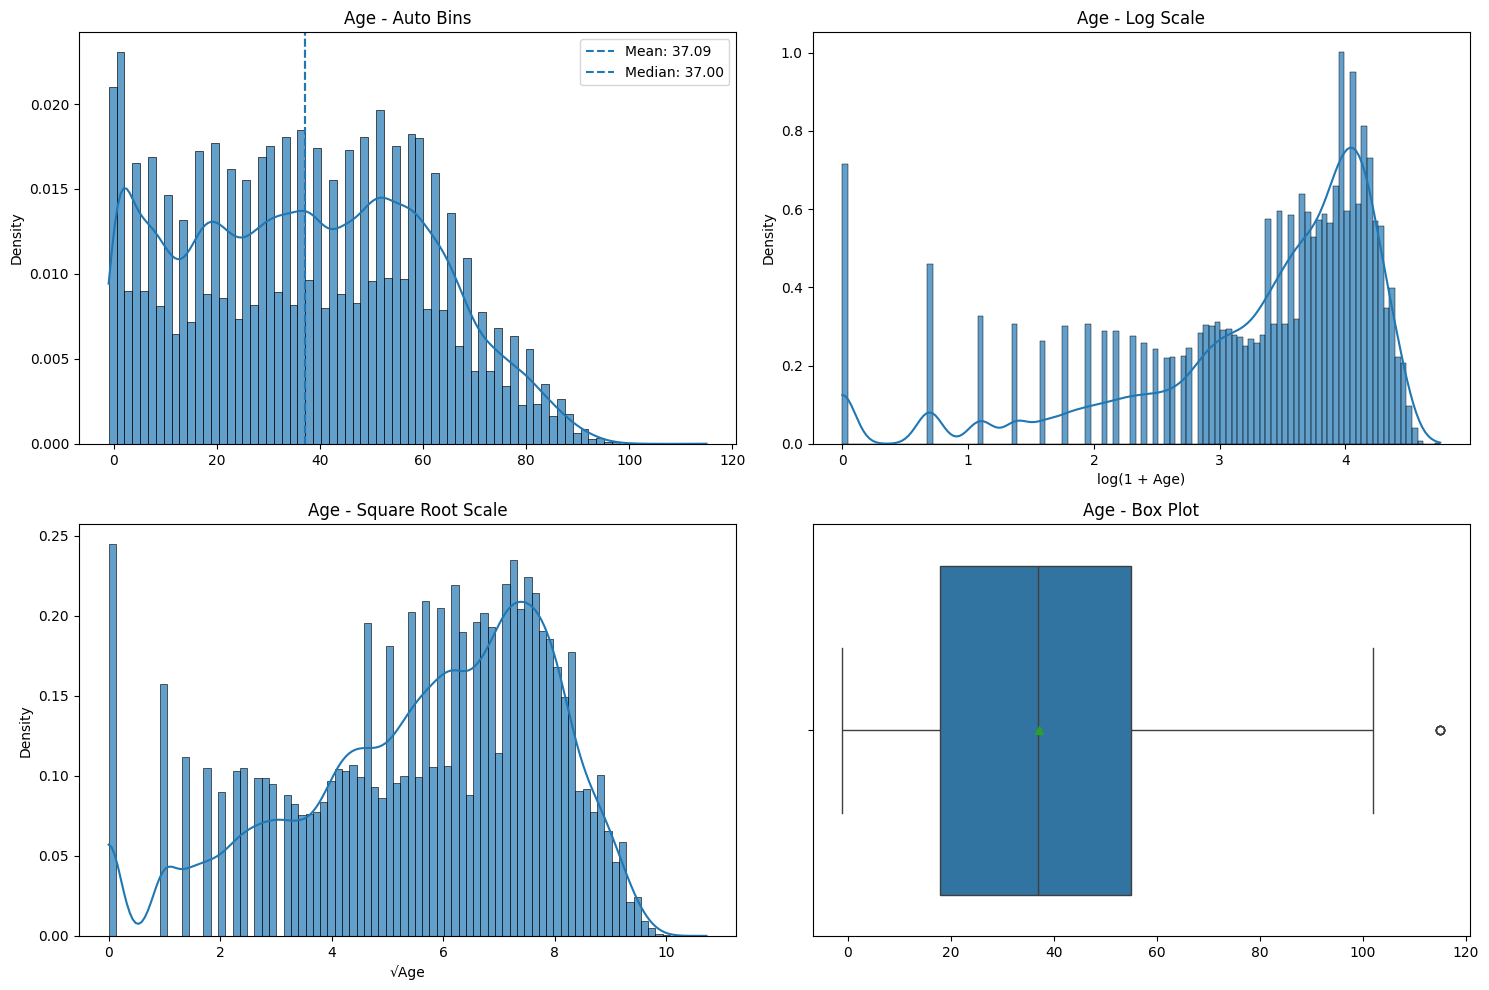

Outliers Report:
Q1: 18.0000
Q3: 55.0000
IQR: 37.0000
Lower fence: -37.5000
Upper fence: 110.5000
Number of Statistical Outlier Candidates: 5
Percent of Statistical Outlier Candidates: 0.0045%


In [10]:
plot_distribution(df["Age"], "Age")
outliers_report(df["Age"])



### Analiza atributa *Age* sa aspekta kvaliteta podataka

Atribut *Age* je numerička diskretna promenljiva (broj godina starosti).  
Analiza pokazuje da nema nedostajućih vrednosti (100% potpunost).

Histogram ukazuje na blagu desnu asimetriju, dok su srednja vrednost (37.09) i medijana (37) gotovo jednake, što govori o relativno stabilnoj raspodeli bez izraženih deformacija.

IQR analiza pokazuje zanemarljiv broj statističkih outliera (0.0045%).  
Međutim, detektovana je jedna logički nevalidna vrednost (*Age = -1*), što predstavlja problem validnosti podataka, a ne statistički ekstrem.

Zaključak: atribut *Age* ima dobar kvalitet u pogledu potpunosti i distribucije, ali zahteva korekciju nevalidne vrednosti.

In [11]:
def analyze_binary_feature(df, feature):
    counts = df[feature].value_counts().sort_index()
    percentages = df[feature].value_counts(normalize=True).sort_index() * 100
    variance = df[feature].var()

    print(f"\n Analiza binarnog atributa: {feature}")
    print("Broj instanci:")
    print(counts)
    print("\nProcenat instanci:")
    print(percentages.round(2).astype(str) + " %")
    print(f"\nVarijansa: {variance:.4f}")

    plt.figure(figsize=(6,4))
    sns.barplot(x=counts.index, y=counts.values, color="steelblue", legend=False)
    plt.title(f"Raspodela vrednosti atributa {feature}")
    plt.xlabel(feature)
    plt.ylabel("Broj instanci")
    plt.show()



 Analiza binarnog atributa: Scholarship
Broj instanci:
Scholarship
0    99666
1    10861
Name: count, dtype: int64

Procenat instanci:
Scholarship
0    90.17 %
1     9.83 %
Name: proportion, dtype: str

Varijansa: 0.0886


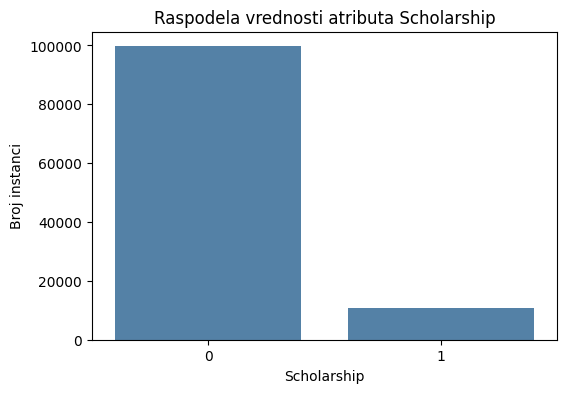

In [12]:
analyze_binary_feature(df, "Scholarship")


**Analiza atributa:** Atribut *Scholarship* je binarnog tipa i pokazuje izrazito neuravnoteženu raspodelu, pri čemu dominantnu vrednost ima 0 (oko 90%). Mali procenat instanci sa vrednošću 1 rezultira niskom varijansom, što ukazuje na ograničenu informativnost ovog atributa. Ovakva raspodela ne predstavlja problem kvaliteta podataka, već karakteristiku posmatrane populacije.


 Analiza binarnog atributa: Hipertension
Broj instanci:
Hipertension
0    88726
1    21801
Name: count, dtype: int64

Procenat instanci:
Hipertension
0    80.28 %
1    19.72 %
Name: proportion, dtype: str

Varijansa: 0.1583


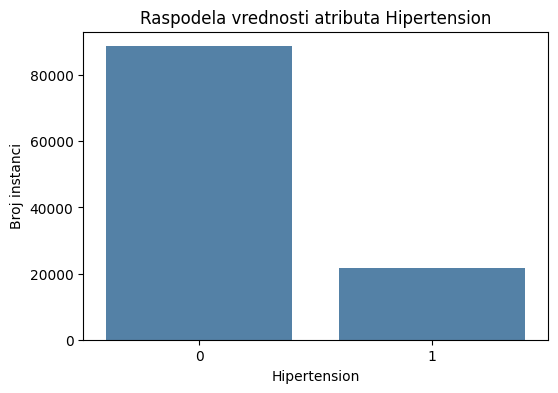

In [13]:
analyze_binary_feature(df, "Hipertension")

**Analiza atributa:** Atribut *Hypertension* je binarnog tipa i pokazuje umereno neuravnoteženu raspodelu, pri čemu vrednost 1 čini približno 20% instanci. Varijansa (0.1583) ukazuje da atribut poseduje određeni nivo informativnosti. Ovakva raspodela ne predstavlja problem kvaliteta podataka, već odražava realnu strukturu populacije.



 Analiza binarnog atributa: Diabetes
Broj instanci:
Diabetes
0    102584
1      7943
Name: count, dtype: int64

Procenat instanci:
Diabetes
0    92.81 %
1     7.19 %
Name: proportion, dtype: str

Varijansa: 0.0667


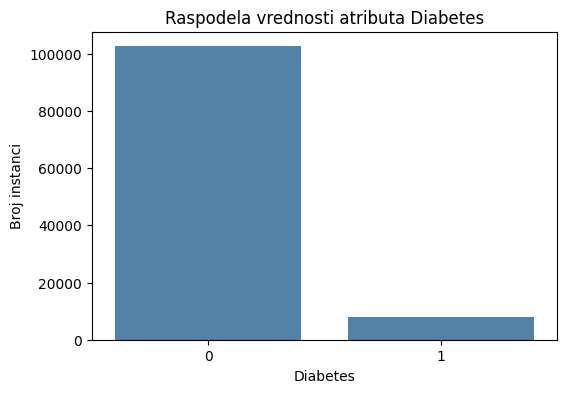

In [14]:
analyze_binary_feature(df, "Diabetes")


**Analiza atributa:** Atribut *Diabetes* je binarnog tipa i pokazuje izraženu neuravnoteženost raspodele, pri čemu vrednost 1 čini približno 7% instanci. Varijansa (0.0667) ukazuje na relativno nizak stepen varijabilnosti i ograničenu informativnost atributa. Ovakva raspodela ne predstavlja problem kvaliteta podataka, već odražava realnu prevalencu posmatranog zdravstvenog stanja u populaciji.



 Analiza binarnog atributa: Alcoholism
Broj instanci:
Alcoholism
0    107167
1      3360
Name: count, dtype: int64

Procenat instanci:
Alcoholism
0    96.96 %
1     3.04 %
Name: proportion, dtype: str

Varijansa: 0.0295


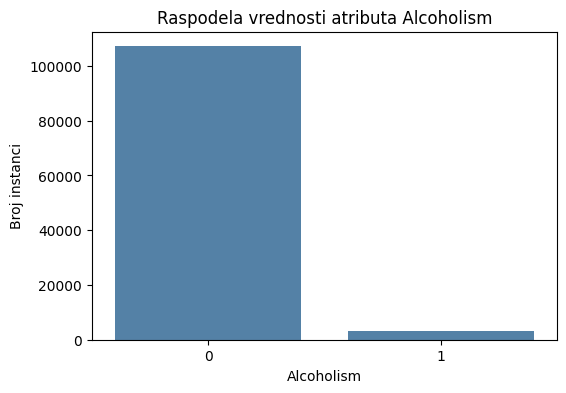

In [15]:
analyze_binary_feature(df, "Alcoholism")


**Analiza atributa:** Atribut *Alcoholism* je binarnog tipa i pokazuje izrazitu neuravnoteženost raspodele, pri čemu vrednost 1 čini približno 3% instanci. Varijansa (0.0295) ukazuje na veoma nizak stepen varijabilnosti i ograničenu informativnost atributa. Ovakva raspodela ne predstavlja problem kvaliteta podataka, već odražava retku pojavu posmatranog stanja u populaciji.



 Analiza binarnog atributa: Handcap
Broj instanci:
Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

Procenat instanci:
Handcap
0    97.97 %
1     1.85 %
2     0.17 %
3     0.01 %
4      0.0 %
Name: proportion, dtype: str

Varijansa: 0.0261


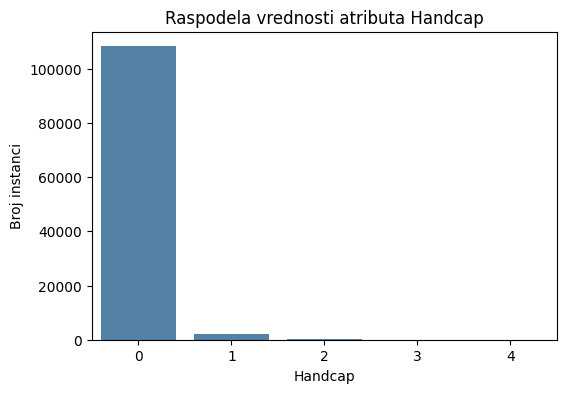

In [16]:
analyze_binary_feature(df, "Handcap")



**Analiza atributa:** Atribut *Handcap* je diskretni ordinalni atribut sa vrednostima od 0 do 4. Raspodela je izrazito neuravnotežena, pri čemu gotovo 98% instanci ima vrednost 0, dok su vrednosti 2, 3 i 4 izuzetno retke. 

Ovakva raspodela ne ukazuje na problem validnosti podataka, ali može predstavljati ograničenje u pogledu statističke reprezentativnosti retkih kategorija. U daljoj analizi može biti opravdano razmotriti agregaciju kategorija radi stabilnijeg modeliranja.


 Analiza binarnog atributa: SMS_received
Broj instanci:
SMS_received
0    75045
1    35482
Name: count, dtype: int64

Procenat instanci:
SMS_received
0    67.9 %
1    32.1 %
Name: proportion, dtype: str

Varijansa: 0.2180


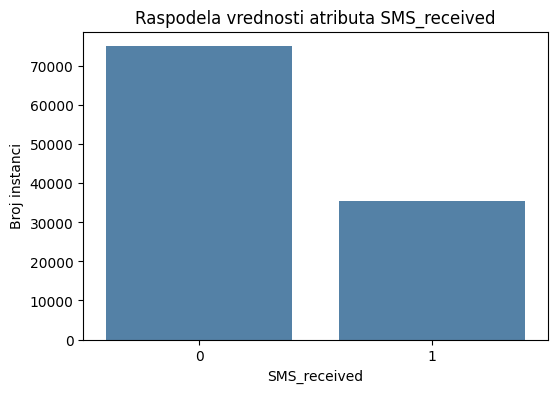

In [17]:
analyze_binary_feature(df, "SMS_received")


**Analiza atributa**: Atribut *SMS_received* je binarnog tipa i ima relativno uravnoteženu raspodelu, pri čemu vrednost 1 čini oko 32% instanci. Varijansa atributa iznosi 0.2180, što ukazuje na visok stepen informativnosti u poređenju sa ostalim binarnimatributima u skupu podataka.

Za razliku od drugih binarnih atributa, *SMS_received* ne pokazuje ekstremnu neuravnoteženost, te predstavlja pozitivan primer kvaliteta podataka.

## 2.3 Analiza kategorijskih feature-a

In [18]:
# izdvajanje kategorijskih atributa (string tip)
categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("Kategorijski atributi:")
for col in categorical_features:
    print(f"- {col}")

print(f"\nUkupan broj kategorijskih atributa: {len(categorical_features)}")


Kategorijski atributi:
- Gender
- ScheduledDay
- AppointmentDay
- Neighbourhood
- No-show

Ukupan broj kategorijskih atributa: 5


### Gender

In [19]:
df['Gender'].dtype


<StringDtype(storage='python', na_value=nan)>

In [20]:
df['Gender'].nunique(dropna=False)


2

In [21]:
df['Gender'].value_counts(normalize=True) * 100


Gender
F    64.997693
M    35.002307
Name: proportion, dtype: float64

In [22]:
df['Gender'].isna().sum()


np.int64(0)

In [23]:
df['Gender'].unique()


<StringArray>
['F', 'M']
Length: 2, dtype: str

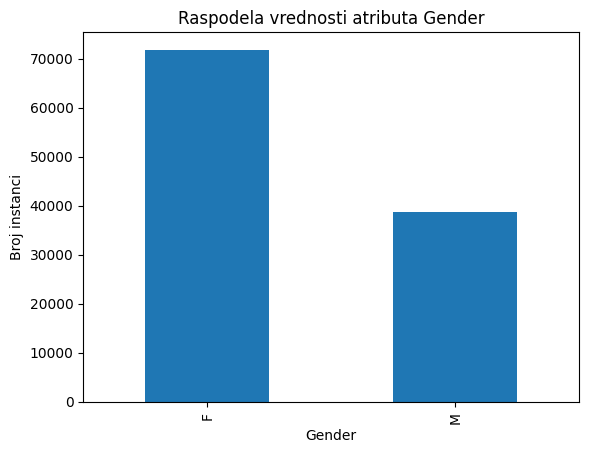

In [24]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='bar')
plt.title('Raspodela vrednosti atributa Gender')
plt.xlabel('Gender')
plt.ylabel('Broj instanci')
plt.show()


Nakon analize feature-a "Gender" možemo zaključiti sledeće:
- to je kategorijski (string) atribut binarnog tipa 
- atribut ima nisku kardinalnost - 2 vrednosti -> to je poželjna osobina u pogledu kvaliteta podataka jer ne uvodi šumove ni sparsity probleme.
- raspodela vrednosti prikazuje umeren disbalansm pri čemu je kategorija F u prednosti sa oko 65% u odnosu na M od približnih 35% instanci. 
- Nedostajuće vrednosti: ne postoje
- Primetna konzistentnost zapisa - sve je M i F, nema varijacija u formatu zapisa 
- Atribut ne predstavlja identifikator, ima jasnu semantičku vrednost i potencijalni informativni značaj

### Neighbourhood 

In [25]:
df['Neighbourhood'].dtype


<StringDtype(storage='python', na_value=nan)>

In [26]:
df['Neighbourhood'].nunique()


81

In [27]:
df['Neighbourhood'].value_counts().head(10)


Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64

In [28]:
df['Neighbourhood'].value_counts(normalize=True).head(10) * 100


Neighbourhood
JARDIM CAMBURI       6.982004
MARIA ORTIZ          5.252110
RESISTÊNCIA          4.008975
JARDIM DA PENHA      3.507740
ITARARÉ              3.179314
CENTRO               3.016458
TABUAZEIRO           2.833697
SANTA MARTHA         2.832792
JESUS DE NAZARETH    2.581270
BONFIM               2.508889
Name: proportion, dtype: float64

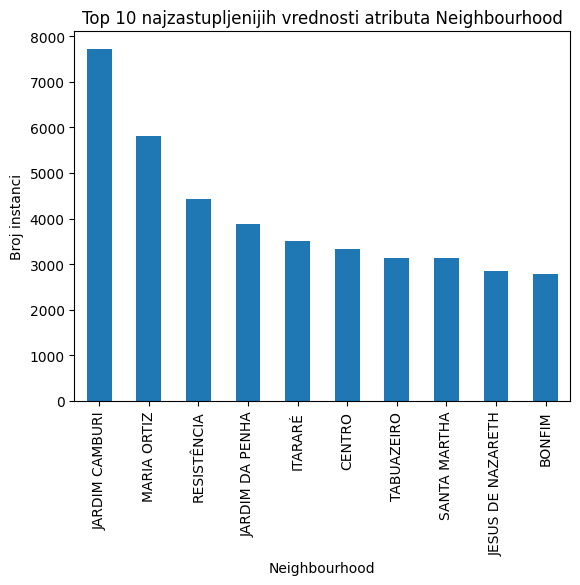

In [29]:
import matplotlib.pyplot as plt

top_n = 10
df['Neighbourhood'].value_counts().head(top_n).plot(kind='bar')
plt.title('Top 10 najzastupljenijih vrednosti atributa Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Broj instanci')
plt.show()


In [30]:
df['Neighbourhood'].isna().sum()


np.int64(0)

In [31]:
df['Neighbourhood'].str.strip().nunique() == df['Neighbourhood'].nunique()
df['Neighbourhood'].unique()[:10]



<StringArray>
[  'JARDIM DA PENHA',     'MATA DA PRAIA', 'PONTAL DE CAMBURI',
         'REPÚBLICA',        'GOIABEIRAS',        'ANDORINHAS',
         'CONQUISTA',    'NOVA PALESTINA',          'DA PENHA',
        'TABUAZEIRO']
Length: 10, dtype: str

**Analiza atributa**:
- Atribut Neighbourhood je kategorijskog (string) tipa i predstavlja lokaciju (oblast) u kojoj je zakazan pregled.
- Atribut ima visoku kardinalnost, sa ukupno 81 različitom vrednošću, što može predstavljati izazov u pogledu kvaliteta podataka i kasnije obrade, naročito u kontekstu modela mašinskog učenja.
- Raspodela vrednosti je neravnomerna, pri čemu mali broj kategorija obuhvata značajan deo instanci. Najzastupljenija vrednost (JARDIM CAMBURI) čini približno 7% ukupnog broja zapisa, dok je prisutan i veći broj ređe zastupljenih kategorija.
- Vizuelna analiza (Top 10 najzastupljenijih vrednosti) potvrđuje postojanje izražene koncentracije instanci u nekoliko kategorija, uz dugačak rep manje zastupljenih vrednosti.
- U atributu Neighbourhood nisu prisutne nedostajuće vrednosti, što ukazuje na dobru potpunost podataka.
- Analiza konzistentnosti zapisa pokazuje da ne postoje varijacije u formatu zapisa (različita velika/mala slova, dodatni razmaci ili duplikati), što ukazuje na visok nivo konzistentnosti podataka.
- Atribut ne predstavlja identifikator, već poseduje jasnu semantičku vrednost. Međutim, zbog visoke kardinalnosti, njegova direktna primena u modelima zahteva dodatnu obradu (npr. grupisanje ili odgovarajući način enkodiranja).

### No-show : Analiza tagret varijable

In [32]:
df['No-show'].nunique(dropna=False)


2

In [33]:
df['No-show'].nunique(dropna=False)


2

In [34]:
df['No-show'].value_counts(normalize=True) * 100


No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

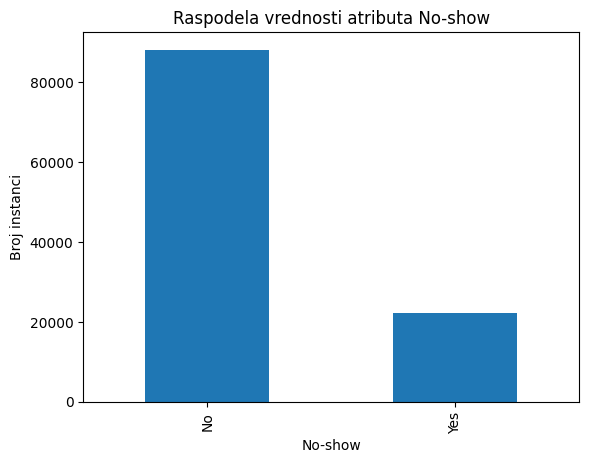

In [35]:
import matplotlib.pyplot as plt

df['No-show'].value_counts().plot(kind='bar')
plt.title('Raspodela vrednosti atributa No-show')
plt.xlabel('No-show')
plt.ylabel('Broj instanci')
plt.show()


In [36]:
df['No-show'].isna().sum()



np.int64(0)

In [37]:
df['No-show'].unique()


<StringArray>
['No', 'Yes']
Length: 2, dtype: str

**Analiza target varijable**: 
- Atribut *No-show* je kategorijskog (string) tipa binarne prirode i predstavlja ciljnu promenljivu (target) u skupu podataka.
- Atribut ima nisku kardinalnost (dve vrednosti), što je poželjna osobina u pogledu obrade podataka i ne uvodi probleme vezane za sparsity.
- Raspodela vrednosti pokazuje umerenu klasnu neravnotežu, pri čemu većinu instanci čini kategorija *No* (pacijent se pojavio), dok je kategorija *Yes* (pacijent se nije pojavio) ređe zastupljena.
- Ova neravnoteža ne predstavlja problem kvaliteta podataka, već karakteristiku posmatranog problema i može zahtevati odgovarajuće strategije evaluacije modela.
- Nedostajuće vrednosti nisu prisutne u ovom atributu, što ukazuje na potpunost podataka.
- Zapisi su potpuno konzistentni, bez varijacija u formatu vrednosti (npr. različita velika/mala slova ili alternativni zapisi).
- Atribut ne predstavlja identifikator, poseduje jasnu semantičku vrednost i ima visok informativni značaj, s obzirom na to da predstavlja ciljnu promenljivu u daljoj analizi.

## 2.4 Analiza vremenskih atributa

(ScheduledDay i AppointmentDay)

Napomena: Iako su ovi atributi inicijalno tipa string, njihova semantička priroda ukazuje da se radi o vremenskim (datetime) atributima, te se analiziraju kao posebna kategorija.

In [38]:
df['ScheduledDay'].dtype
df['AppointmentDay'].dtype


<StringDtype(storage='python', na_value=nan)>

Oba atributa su inicijalno tipa string, ali predtavljaju vremenske odrednice. 
- ScheduledDay predstavlja trenutak zakazivanja pregleda
- AppointmentDay - datum održavanja pregleda

->pretvorićemo/konvertovati u datetime radi pogodnije dalje analize

In [39]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])


Konverzija prolazi bez grešaka -> format zapisa kod svih instanci je bio ispravan

In [40]:
df['ScheduledDay'].isna().sum()
df['AppointmentDay'].isna().sum()


np.int64(0)

Nedostajuće vrednosti nisu prisutne.

In [41]:
(df['AppointmentDay'].dt.normalize() < df['ScheduledDay'].dt.normalize()).sum()

np.int64(5)

### ScheduledDay i AppointmentDay

Iako su atributi *ScheduledDay* i *AppointmentDay* inicijalno učitani kao string, njihova semantička priroda ukazuje da predstavljaju vremenske odrednice, te je izvršena konverzija u `datetime` format radi pravilne analize.

- Konverzija je prošla bez grešaka, što ukazuje na validan format zapisa u svim instancama.
- Nedostajuće vrednosti nisu prisutne, što potvrđuje potpunost ovih atributa.
- Proverom logičke konzistentnosti identifikovano je nekoliko slučajeva gde je *AppointmentDay* pre *ScheduledDay* (negativno vreme čekanja), što predstavlja problem validnosti podataka i zahteva korekciju ili uklanjanje takvih instanci.

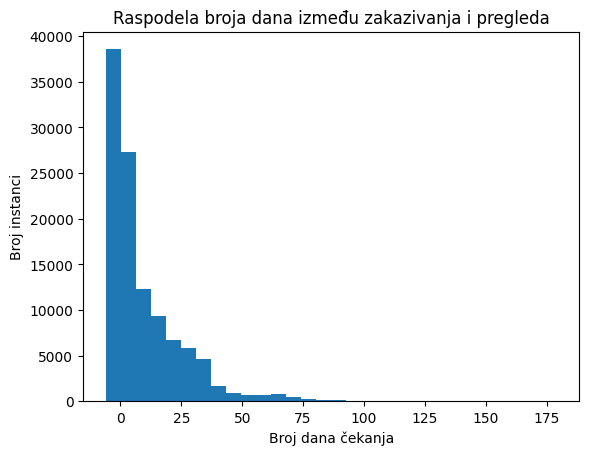

In [42]:
df['WaitingDays'] = (
    df['AppointmentDay'].dt.normalize() 
    - df['ScheduledDay'].dt.normalize()
).dt.days


df['WaitingDays'].plot(kind='hist', bins=30)
plt.title('Raspodela broja dana između zakazivanja i pregleda')
plt.xlabel('Broj dana čekanja')
plt.ylabel('Broj instanci')
plt.show()


### Atribut WaitingDays (vreme čekanja)

Definisan je atribut *WaitingDays* kao razlika između datuma pregleda i datuma zakazivanja (u danima). Raspodela *WaitingDays* pokazuje izraženu desnu asimetriju: najveći broj pregleda zakazan je za isti dan ili u kratkom roku, dok manji broj instanci ima znatno duže vreme čekanja.

Atribut *WaitingDays* predstavlja informativnu izvedenu promenljivu i omogućava direktnu analizu uticaja vremena čekanja na pojavu *no-show*.



In [43]:
df[df['WaitingDays'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitingDays
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1


Na osnovu ovog vidimo da postoje negativne vrednosti koje ukazuju na to da je AppointmentDay < ScheduledDay -> pregled je zakazan nakon što je trebao biti obavljen! 
Ovo jasno ukazuje na problem kvaliteta podataka jer predstavlja logičku nekonzistentnost

In [44]:
df['WaitingDays'].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64

Na osnovu ovoga vidimo da je distribucija desno simetrična, ima male negativne greške i ima veće vrednosti

## 2.5 Analiza zavisnosti među atributima

In [45]:
# izdvajanje numerickih atributa 
numerical_df = df.select_dtypes(include=["int64", "float64"])

numerical_df.shape


(110527, 10)

In [46]:
corr_matrix = numerical_df.corr(method="pearson")
corr_matrix


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,WaitingDays
PatientId,1.000000,0.004039,-0.004139,-0.002880,-0.006441,0.001605,0.011011,-0.007916,-0.009749,-0.001467
AppointmentID,0.004039,1.000000,-0.019126,0.022615,0.012752,0.022628,0.032944,0.014106,-0.256618,-0.771830
Age,-0.004139,-0.019126,1.000000,-0.092457,0.504586,0.292391,0.095811,0.078033,0.012643,0.034820
Scholarship,-0.002880,0.022615,-0.092457,1.000000,-0.019729,-0.024894,0.035022,-0.008586,0.001194,-0.030421
Hipertension,-0.006441,0.012752,0.504586,-0.019729,1.000000,0.433086,0.087971,0.080083,-0.006267,-0.017215
Diabetes,0.001605,0.022628,0.292391,-0.024894,0.433086,1.000000,0.018474,0.057530,-0.014550,-0.027188
Alcoholism,0.011011,0.032944,0.095811,0.035022,0.087971,0.018474,1.000000,0.004648,-0.026147,-0.038519
Handcap,-0.007916,0.014106,0.078033,-0.008586,0.080083,0.057530,0.004648,1.000000,-0.024161,-0.019843
SMS_received,-0.009749,-0.256618,0.012643,0.001194,-0.006267,-0.014550,-0.026147,-0.024161,1.000000,0.398145
WaitingDays,-0.001467,-0.771830,0.034820,-0.030421,-0.017215,-0.027188,-0.038519,-0.019843,0.398145,1.000000


In [47]:
def plot_spearman_heatmap(df, title, mask_threshold=0.5):
    df = df.select_dtypes(include=np.number)
    df = df.dropna()

    spearman_corr = df.corr(method="spearman")

    mask = np.logical_and(
        spearman_corr > -mask_threshold,
        spearman_corr < mask_threshold
    )
    mask = mask.values.copy()
    mask[np.triu_indices_from(mask)] = True

    plt.figure(figsize=(12, 9)) 
    sns.heatmap(
        spearman_corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        mask=mask,
        square=True,
        cbar_kws={"shrink": 0.7},
        linecolor="grey",
        linewidths=0.4
    )

    plt.title(f"Spearman correlation heatmap – {title}", fontsize=11)
    plt.tight_layout()
    plt.show()



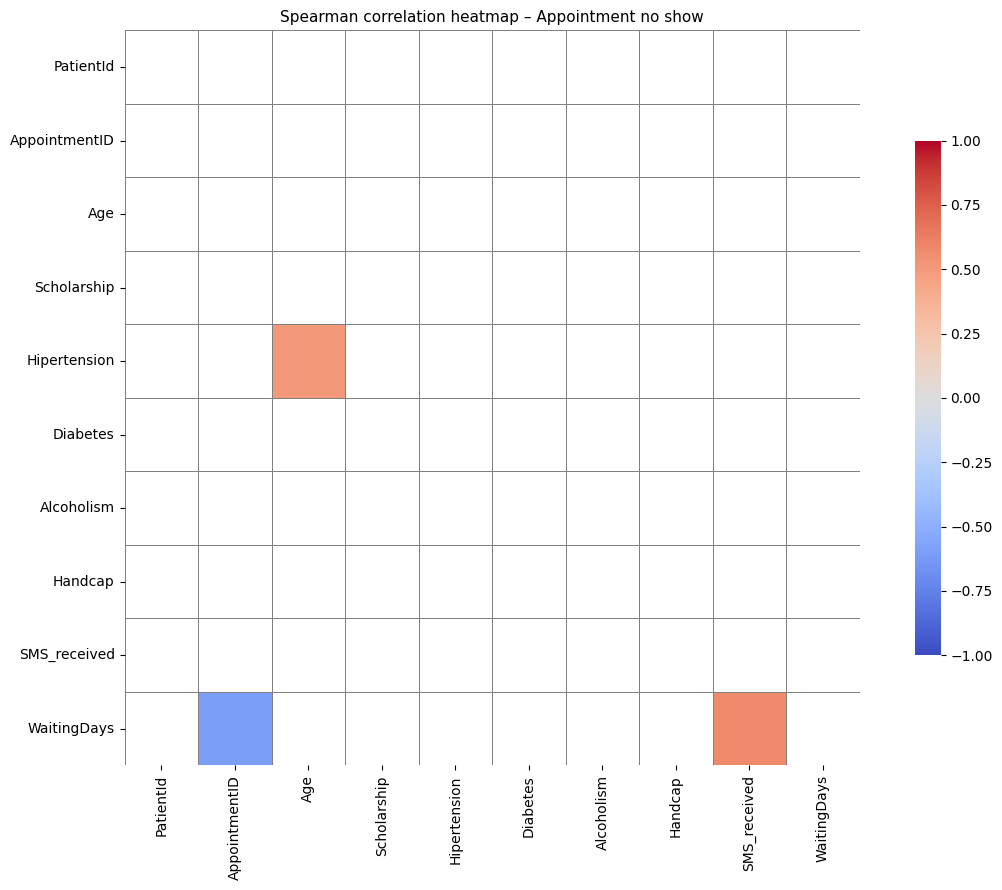

In [48]:
plot_spearman_heatmap(df, "Appointment no show", mask_threshold=0.5)

### Korelacije numeričkih atributa

Korelaciona analiza (Spearman) primenjena je kako bi se identifikovale potencijalne monotone veze između numeričkih atributa. Identifikacioni atributi (*PatientId*, *AppointmentID*) ne poseduju numeričko značenje i zbog toga se ne interpretiraju kroz korelacije, već se tretiraju kao nerelevantni za modeliranje.

Uočene su očekivane veze, npr. između starosti i hipertenzije, kao i između *WaitingDays* i pojedinih atributa vezanih za proces zakazivanja.

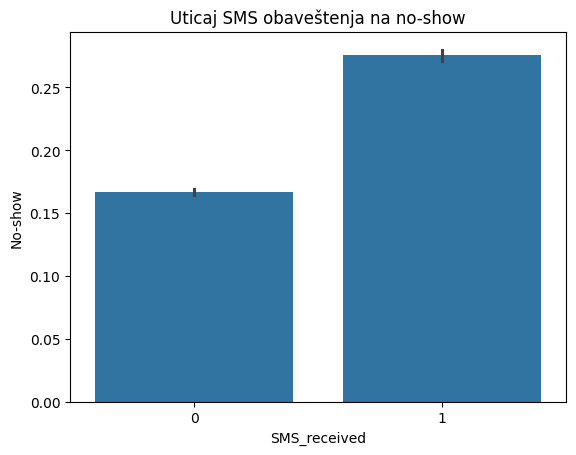

In [49]:
sns.barplot(
    x='SMS_received',
    y=df['No-show'].map({'Yes': 1, 'No': 0}),
    data=df
)
plt.title("Uticaj SMS obaveštenja na no-show")
plt.show()


Prikaz odnosa između atributa SMS_received i ciljne promenljive pokazuje da je stopa no-show veća kod pacijenata koji su primili SMS obaveštenje u odnosu na one koji ga nisu primili. Ovakav rezultat ne mora značiti uzročni efekat SMS obaveštenja, već može ukazivati na pristrasnost u procesu slanja poruka (npr. SMS se češće šalje pacijentima sa dužim vremenom čekanja, što je povezano sa većom verovatnoćom nepojavljivanja).

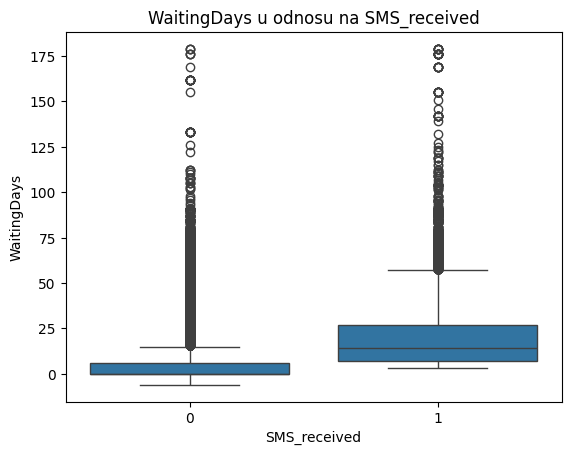

In [50]:
sns.boxplot(x='SMS_received', y='WaitingDays', data=df)
plt.title("WaitingDays u odnosu na SMS_received")
plt.show()


Daljom analizom odnosa između atributa SMS_received i vremena čekanja (WaitingDays) uočava se da pacijenti koji su primili SMS obaveštenje imaju znatno duže vreme čekanja u odnosu na one kojima poruka nije poslata. Ovo ukazuje da slanje SMS obaveštenja nije nasumično, već je povezano sa terminima koji nose veći rizik od nepojavljivanja. Samim tim, uočena veća stopa no-show kod pacijenata koji su primili SMS verovatno je posledica dužeg vremena čekanja, a ne direktan efekat samog obaveštenja.

*kako citamo ove box plotove?*
- vidimo da je medijana kod nije poslat sms blizu 0-2 dana dok je medijana kod poslat sms blizu 10-15 dana -> snazan signal za pocetak
- irq: uzan kod nije poslat sms to znaci da vecina termina ima kratko cekanje dok je kod ovih sa porukom siri raspon i to vise ide dalje u desno
- obe grupe imaju statističke outliere ali kod sms =1 ih ima vise

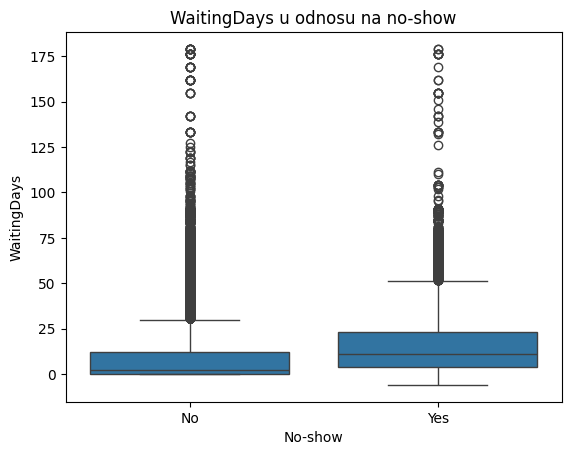

In [51]:
sns.boxplot(x='No-show', y='WaitingDays', data=df)
plt.title("WaitingDays u odnosu na no-show")
plt.show()

Duže vreme čekanja značajno povećava verovatnoću nepojavljivanja pacijenta.

### Stratifikovana analiza uticaja SMS obaveštenja uz kontrolu WaitingDays ###

Nakon utvrđivanja da vreme čekanja značajno utiče na verovatnoću nepojavljivanja, postavlja se pitanje da li je uočena veća stopa no-show kod pacijenata koji su primili SMS zapravo posledica dužeg vremena čekanja.

Radi provere potencijalnog konfuzionog efekta varijable WaitingDays, izvršena je stratifikacija podataka po intervalima vremena čekanja.

In [52]:
# podela vremena cekanja u intervale
bins = [-1, 0, 3, 7, 14, 30, 180]
labels = ["0", "1-3", "4-7", "8-14", "15-30", "30+"]

df["WaitingGroup"] = pd.cut(df["WaitingDays"], bins=bins, labels=labels)

# binarna verzija ciljne promenljive
df["NoShow_binary"] = df["No-show"].map({"Yes": 1, "No": 0})

# stratifikovana analiza
stratified = (
    df
    .groupby(["WaitingGroup", "SMS_received"])["NoShow_binary"]
    .mean()
    .unstack()
)

stratified


SMS_received,0,1
WaitingGroup,,
0,0.046469,NaN
1-3,0.229937,0.213024
4-7,0.271112,0.239711
8-14,0.337582,0.281125
15-30,0.368705,0.298004
30+,0.375252,0.302028


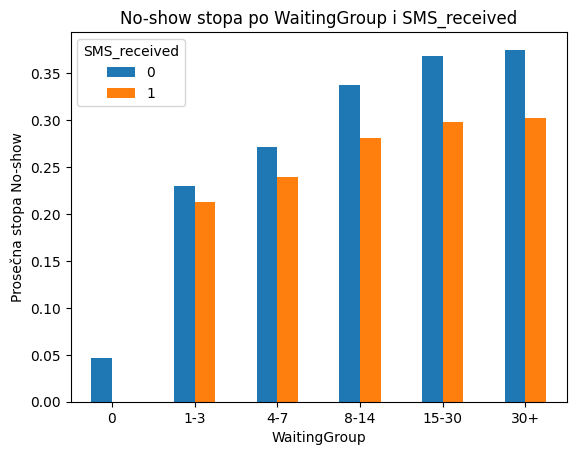

In [53]:
stratified.plot(kind="bar")
plt.title("No-show stopa po WaitingGroup i SMS_received")
plt.ylabel("Prosečna stopa No-show")
plt.xlabel("WaitingGroup")
plt.xticks(rotation=0)
plt.show()

### Stratifikovana analiza uz kontrolu WaitingDays ###

Nakon stratifikacije pidataka po intervalima vremena čekanja, uočeno je da unutar svake grupe pacijenata sa sličnim trajanjem čekanja, stopa nepojavljivanja dosledno ostaje niža kod pacijeata koji su primili sms obaveštenje. 

Iako je u bivarijatnoj analizi delovalo da pacijenti sa primljenim SMS-om imaju veću stopu no-show, stratifikovana analiza pokazuje da je taj efekat posledica činjenice da se SMS češće šalje pacijentima sa dužim vremenom čekanja, što je već povezano sa većim rizikom nepojavljivanja.

Kontrolom varijable WaitingDays, SMS obaveštenje pokazuje konzistentan zaštitni efekat, smanjujući verovatnoću nepojavljivanja unutar svakog intervala čekanja.

Ovaj nalaz predstavlja primer Simpsonovog paradoksa, gde agregirana analiza može dovesti do pogrešnih zaključaka ukoliko se ne kontrolišu relevantni faktori.

# 3. Modeliranje i evaluacija uticaja kvaliteta podataka

## 3.1 Formulacija problema 

Cilj modeliranja jeste predikcija verovatnoće nepojavljivanja pacijenata na zakazani pregled (No-show). Problem se formalno posmatra kao binarna klasifikacija, gde target varijabla ima vrednosti:
- 0 - pacijent se pojavio
- 1 - pacijent se nije pojavio

Na osnovu prethodne analize, identifikovani su faktori koji potencijalno utiču na nepojavljivanje, uključujući vreme čekanja, prijem SMS obaveštenja kao i druge karakteristike.

## 3.2 Bazni modeli

Kao početna referentna tačka (baseline) korišćeni su modeli trenirani nad minimalno obrađenim skupom podataka. Cilj baznog modela je da prikaže performanse u uslovima pre uvođenja dodatnih unapređenja (npr. izvedenih atributa poput WaitingDays i tehnika za ublažavanje disbalansa klasa), čime se omogućava jasnije poređenje sa unapređenim pristupom.

U baznom eksperimentu:

- izbačene su identifikacione kolone (PatientId, AppointmentID) jer nemaju prediktivnu vrednost i mogu dovesti do prenaučenosti (memorization),

- datumske kolone (ScheduledDay, AppointmentDay) nisu direktno korišćene u baznoj varijanti (informacija iz njih biće iskorišćena u unapređenom modelu kroz atribut WaitingDays),

- ciljna promenljiva je kodirana u binarni oblik (NoShow_binary),

- podela na trening i test skup izvršena je pre enkodovanja i skaliranja, kako bi se izbeglo curenje informacija (data leakage).

Kao bazni modeli razmatrani su logistička regresija (interpretabilan linearni model) i Random Forest (nelinearni model), čime se omogućava poređenje različitih pretpostavki o strukturi podataka.

### Preprocesiranje podataka

In [54]:
#izbacujemo identifikatore, datumske kolone i target u oba oblika
X = df.drop(columns=[
    "No-show",
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "NoShow_binary",
    "AppointmentDay",
    "WaitingDays",
    "WaitingGroup"
    
])
y = df["NoShow_binary"]

In [55]:
list(X.columns)

['Gender',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hipertension',
 'Diabetes',
 'Alcoholism',
 'Handcap',
 'SMS_received']

In [56]:
from sklearn.model_selection import train_test_split

#delimo na test i trening skup
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [57]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_scaled, y_train)

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluacija 

In [60]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# =========================
# BASE LOGISTIC REGRESSION
# =========================

y_pred_base = model_base.predict(X_test_scaled)
y_proba_base = model_base.predict_proba(X_test_scaled)[:, 1]

report_base = classification_report(y_test, y_pred_base, output_dict=True)
report_base_df = pd.DataFrame(report_base).transpose()

roc_auc_base = roc_auc_score(y_test, y_proba_base)

# dodamo roc_auc kao dodatnu kolonu i popunimo samo u posebnom redu
report_base_df["roc_auc"] = None
report_base_df.loc["ROC-AUC", "roc_auc"] = roc_auc_base

report_base_df = report_base_df.round(3)

print("===== BASE LOGISTIC =====")
display(report_base_df)

# (opciono) da odmah vidis ono sto ti je najbitnije
print("Recall (No-show=1):", report_base_df.loc["1", "recall"])


# =========================
# BASE RANDOM FOREST
# =========================

y_pred_rf_base = rf_base.predict(X_test)
y_proba_rf_base = rf_base.predict_proba(X_test)[:, 1]

report_rf_base = classification_report(y_test, y_pred_rf_base, output_dict=True)
report_rf_base_df = pd.DataFrame(report_rf_base).transpose()

roc_auc_rf_base = roc_auc_score(y_test, y_proba_rf_base)

report_rf_base_df["roc_auc"] = None
report_rf_base_df.loc["ROC-AUC", "roc_auc"] = roc_auc_rf_base

report_rf_base_df = report_rf_base_df.round(3)

print("===== BASE RANDOM FOREST =====")
display(report_rf_base_df)

print("Recall (No-show=1):", report_rf_base_df.loc["1", "recall"])

===== BASE LOGISTIC =====


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

,precision,recall,f1-score,support,roc_auc
0,0.798,1.000,0.888,17642.000,None
1,0.000,0.000,0.000,4464.000,None
accuracy,0.798,0.798,0.798,0.798,None
macro avg,0.399,0.500,0.444,22106.000,None
weighted avg,0.637,0.798,0.708,22106.000,None
ROC-AUC,NaN,NaN,NaN,NaN,0.610208


Recall (No-show=1): 0.0
===== BASE RANDOM FOREST =====


,precision,recall,f1-score,support,roc_auc
0,0.808,0.916,0.858,17642.000,None
1,0.292,0.137,0.187,4464.000,None
accuracy,0.759,0.759,0.759,0.759,None
macro avg,0.550,0.527,0.522,22106.000,None
weighted avg,0.703,0.759,0.723,22106.000,None
ROC-AUC,NaN,NaN,NaN,NaN,0.582573


Recall (No-show=1): 0.137


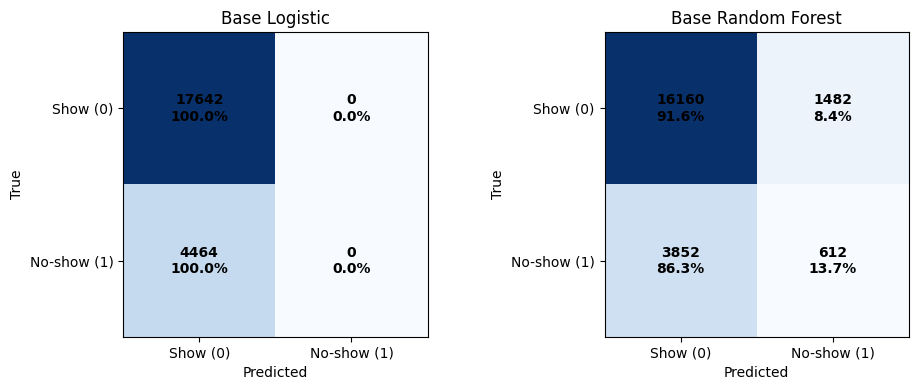

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=12)

    classes = ["Show (0)", "No-show (1)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{cm[i,j]}\n{cm_percent[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    return im

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im1 = plot_cm(axes[0], y_test, y_pred_base, "Base Logistic")
im2 = plot_cm(axes[1], y_test, y_pred_rf_base, "Base Random Forest")

plt.tight_layout()
plt.show()

Logistička regresija u baznoj varijanti klasifikuje gotovo sve instance kao većinsku klasu (Show), što rezultuje potpunim izostankom detekcije No-show slučajeva. Ovaj nalaz jasno potvrđuje da disbalans klasa predstavlja dominantan problem kvaliteta podataka

 Evaluacija baznog modela

Rezultati evaluacije baznog modela prikazani su u Tabeli X. Iako model ostvaruje relativno visoku tačnost (Accuracy = 0.798) i umerenu ROC-AUC vrednost (0.725), detaljna analiza metrika po klasama pokazuje značajne nedostatke.

Posebno je uočljivo da je Recall za klasu No-show izuzetno nizak (0.006), što ukazuje da model gotovo u potpunosti ne uspeva da identifikuje pacijente koji se neće pojaviti na zakazani pregled. Drugim rečima, model dominantno predviđa većinsku klasu (pojavili se), što je posledica neuravnoteženosti podataka.

Ovakav rezultat potvrđuje da bazni model, iako tehnički funkcionalan, nije adekvatan za praktičnu primenu u kontekstu predikcije nepojavljivanja pacijenata.

## 3.3 Improved model

### Feature engineering

In [62]:
df2 = df[df["WaitingDays"] >= 0].copy()


Atribut WaitingDays je izveden (feature engineering) iz postojećih vremenskih atributa i uveden je samo u unapređenom modelu radi hvatanja efekta vremena čekanja na verovatnoću nedolaska.

### Preprocesiranje podataka

In [63]:
y = df2["NoShow_binary"]

In [64]:
X = df2.drop(columns=[
    "No-show", "NoShow_binary",
    "PatientId", "AppointmentID",
    "ScheduledDay", "AppointmentDay",
    "WaitingGroup"   # drop jer je izveden iz WaitingDays (redundant)
])


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegression

model_improved = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_improved.fit(X_train_scaled, y_train)

from sklearn.ensemble import RandomForestClassifier

rf_improved = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_improved.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluacija improved modela

In [72]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# =================================
# IMPROVED LOGISTIC REGRESSION
# =================================

y_pred_improved = model_improved.predict(X_test_scaled)
y_proba_improved = model_improved.predict_proba(X_test_scaled)[:, 1]

report_improved = classification_report(
    y_test,
    y_pred_improved,
    output_dict=True
)

report_improved_df = pd.DataFrame(report_improved).transpose()

roc_auc_improved = roc_auc_score(y_test, y_proba_improved)

report_improved_df["roc_auc"] = None
report_improved_df.loc["ROC-AUC", "roc_auc"] = roc_auc_improved

report_improved_df = report_improved_df.round(3)

print("===== IMPROVED LOGISTIC =====")
display(report_improved_df)

print("Recall (No-show=1):", report_improved_df.loc["1", "recall"])

# =================================
# IMPROVED RANDOM FOREST
# =================================

y_pred_rf_improved = rf_improved.predict(X_test)
y_proba_rf_improved = rf_improved.predict_proba(X_test)[:, 1]

report_rf_improved = classification_report(
    y_test,
    y_pred_rf_improved,
    output_dict=True
)

report_rf_improved_df = pd.DataFrame(report_rf_improved).transpose()

roc_auc_rf_improved = roc_auc_score(y_test, y_proba_rf_improved)

report_rf_improved_df["roc_auc"] = None
report_rf_improved_df.loc["ROC-AUC", "roc_auc"] = roc_auc_rf_improved

report_rf_improved_df = report_rf_improved_df.round(3)

print("===== IMPROVED RANDOM FOREST =====")
display(report_rf_improved_df)

print("Recall (No-show=1):", report_rf_improved_df.loc["1", "recall"])

===== IMPROVED LOGISTIC =====


,precision,recall,f1-score,support,roc_auc
0,0.863,0.674,0.757,17642.000,None
1,0.309,0.576,0.402,4463.000,None
accuracy,0.654,0.654,0.654,0.654,None
macro avg,0.586,0.625,0.579,22105.000,None
weighted avg,0.751,0.654,0.685,22105.000,None
ROC-AUC,NaN,NaN,NaN,NaN,0.664441


Recall (No-show=1): 0.576
===== IMPROVED RANDOM FOREST =====


,precision,recall,f1-score,support,roc_auc
0,0.826,0.884,0.854,17642.000,None
1,0.366,0.263,0.306,4463.000,None
accuracy,0.759,0.759,0.759,0.759,None
macro avg,0.596,0.574,0.580,22105.000,None
weighted avg,0.733,0.759,0.744,22105.000,None
ROC-AUC,NaN,NaN,NaN,NaN,0.700108


Recall (No-show=1): 0.263


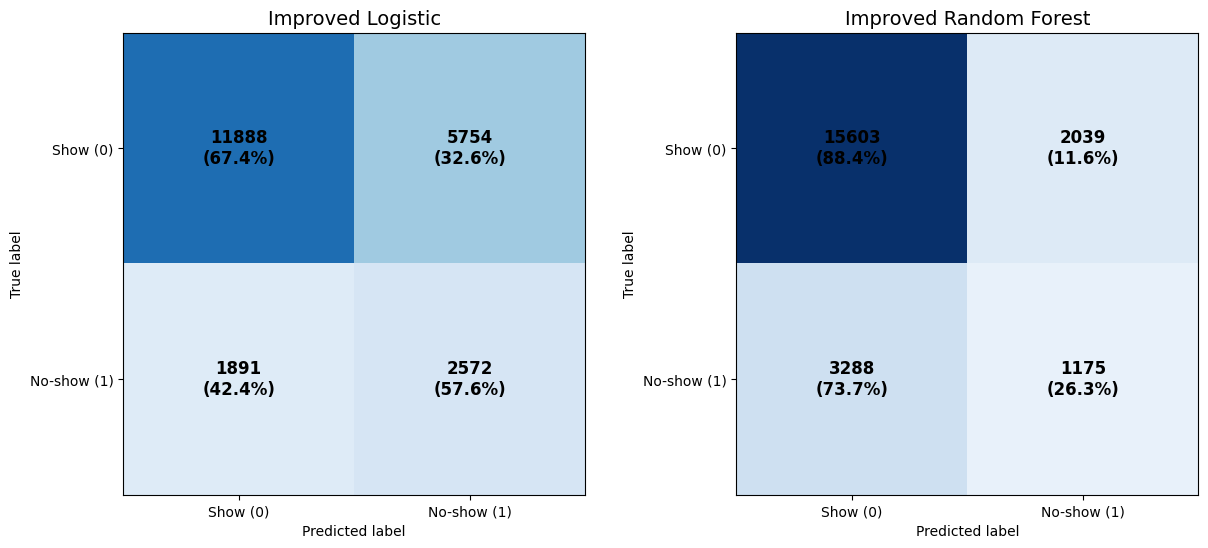

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm_log = confusion_matrix(y_test, y_pred_improved)
cm_rf  = confusion_matrix(y_test, y_pred_rf_improved)

# Zajednička skala
vmax = max(cm_log.max(), cm_rf.max())

fig, axes = plt.subplots(1, 2, figsize=(14,6))

titles = ["Improved Logistic", "Improved Random Forest"]
cms = [cm_log, cm_rf]
classes = ["Show (0)", "No-show (1)"]

for ax, cm, title in zip(axes, cms, titles):

    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=vmax)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    cm_percent = cm / cm.sum(axis=1)[:, np.newaxis] * 100

    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{cm[i,j]}\n({cm_percent[i,j]:.1f}%)",
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold")

plt.subplots_adjust(wspace=0.3)
plt.show()

U unapređenom modelu primećuje se povećanje broja tačno detektovanih nedolazaka (TP), uz smanjenje broja propuštenih slučajeva (FN), što ukazuje na poboljšanje recall metrike za manjinsku klasu

In [74]:
import pandas as pd
import numpy as np

# Kreiranje pregledne tabele
compare_all = pd.DataFrame({
    "Base Logistic": {
        "Accuracy": report_base_df.loc["accuracy", "precision"],
        "Precision (No-show)": report_base_df.loc["1", "precision"],
        "Recall (No-show)": report_base_df.loc["1", "recall"],
        "F1-score (No-show)": report_base_df.loc["1", "f1-score"],
        "ROC-AUC": report_base_df.loc["ROC-AUC", "roc_auc"]
    },
    "Base Random Forest": {
        "Accuracy": report_rf_base_df.loc["accuracy", "precision"],
        "Precision (No-show)": report_rf_base_df.loc["1", "precision"],
        "Recall (No-show)": report_rf_base_df.loc["1", "recall"],
        "F1-score (No-show)": report_rf_base_df.loc["1", "f1-score"],
        "ROC-AUC": report_rf_base_df.loc["ROC-AUC", "roc_auc"]
    },
    "Improved Logistic": {
        "Accuracy": report_improved_df.loc["accuracy", "precision"],
        "Precision (No-show)": report_improved_df.loc["1", "precision"],
        "Recall (No-show)": report_improved_df.loc["1", "recall"],
        "F1-score (No-show)": report_improved_df.loc["1", "f1-score"],
        "ROC-AUC": report_improved_df.loc["ROC-AUC", "roc_auc"]
    },
    "Improved Random Forest": {
        "Accuracy": report_rf_improved_df.loc["accuracy", "precision"],
        "Precision (No-show)": report_rf_improved_df.loc["1", "precision"],
        "Recall (No-show)": report_rf_improved_df.loc["1", "recall"],
        "F1-score (No-show)": report_rf_improved_df.loc["1", "f1-score"],
        "ROC-AUC": report_rf_improved_df.loc["ROC-AUC", "roc_auc"]
    }
}).T

compare_all = compare_all.round(3)

# Stilizacija – isticanje najboljih vrednosti po koloni
styled_table = (
    compare_all
    .style
    .highlight_max(axis=0, color="#d4edda")  # svetlo zelena za najbolji rezultat
    .set_caption("Uporedna analiza performansi base i unapređenih modela")
)

display(styled_table)

,Accuracy,Precision (No-show),Recall (No-show),F1-score (No-show),ROC-AUC
Base Logistic,0.798000,0.000000,0.000000,0.000000,0.610000
Base Random Forest,0.759000,0.292000,0.137000,0.187000,0.583000
Improved Logistic,0.654000,0.309000,0.576000,0.402000,0.664000
Improved Random Forest,0.759000,0.366000,0.263000,0.306000,0.700000


Rezultati pokazuju da osnovni modeli nisu adekvatno adresirali problem disbalansa klasa, pri čemu je bazni logistički model u potpunosti ignorisao manjinsku klasu. Uvođenjem izvedenog atributa WaitingDays i primenom balansiranja klasa, unapređeni modeli ostvaruju značajno poboljšanje u detekciji no-show slučajeva. Posebno se ističe unapređeni logistički model, koji postiže recall od 57.6%, čime više nego četvorostruko nadmašuje bazne modele. Random Forest model pokazuje najbolji ROC-AUC (0.700), ali uz niži recall u odnosu na logistički model. Rezultati potvrđuju da feature engineering i balansiranje klasa imaju ključnu ulogu u unapređenju performansi modela.

# 4. Zakljucak

U ovom radu sprovedena je analiza predikcije nedolazaka pacijenata (No-show) korišćenjem baznih i unapređenih modela mašinskog učenja. Početna analiza pokazala je izražen disbalans klasa, pri čemu je većinu instanci činila klasa pacijenata koji su se pojavili na zakazanom terminu. Bazni logistički model, uprkos relativno visokoj tačnosti (79.8%), u potpunosti je zanemario manjinsku klasu, što je rezultovalo recall vrednošću od 0. Ovaj rezultat potvrđuje da accuracy metrika nije adekvatna za evaluaciju modela u uslovima disbalansa.

Uvođenjem izvedenog atributa WaitingDays, koji kvantifikuje vremenski razmak između zakazivanja i termina pregleda, kao i primenom mehanizma balansiranja klasa putem parametra class_weight, ostvareno je značajno poboljšanje performansi. Unapređeni logistički model postiže recall od 57.6%, čime uspešno identifikuje više od polovine pacijenata koji se neće pojaviti na pregledu. Time je postignuto suštinsko unapređenje u odnosu na bazne modele.

Random Forest model u unapređenoj verziji ostvaruje najvišu ROC-AUC vrednost (0.700), što ukazuje na bolju ukupnu sposobnost razdvajanja klasa. Međutim, u kontekstu praktične primene, gde je identifikacija rizičnih pacijenata prioritet, unapređeni logistički model pokazuje veću korisnost zbog znatno višeg recall-a.

Rezultati potvrđuju da kvalitet podataka, pravilna obrada disbalansa i pažljivo izvedeni atributi imaju ključnu ulogu u unapređenju performansi modela. Feature engineering, zajedno sa adekvatnom evaluacijom metrika prilagođenih problemu, pokazao se kao presudan faktor u razvoju pouzdanog prediktivnog sistema.